In [1]:
# import mitsuba
import math

from scipy import constants as const

# import drjit
import drjit as dr
import matplotlib.pyplot as plt
import numpy as np

import mitsuba as mi

# colocar el valor de spectral
mi.set_variant("cuda_ad_spectral")

from mitsuba import ScalarTransform4f as T


In [2]:
def load_sensor_spectral(
    r: float,
    phi: float,
    theta: float,
    wave_lengths: np.ndarray,
    sigma: float,
    k: float = 3,
    n_wavelents: int = 5,
):
    """
    Load a sensor with Gaussian response.

    Args:
        r (float): Radius of the sensor.
        phi (float): Azimuthal angle in degrees.
        theta (float): Polar angle in degrees.
        wave_lengths (np.ndarray): Wavelengths for the Gaussian response.
        sigma (float): Standard deviation of the Gaussian.
        k (float, optional): Number of standard deviations. Default is 3.
        n_wavelents (int, optional): Number of wavelengths. Default is 5.
    """
    z = r * dr.sin(math.radians(theta))
    y = r * dr.cos(math.radians(theta)) * dr.sin(math.radians(phi))
    x = r * dr.cos(math.radians(theta)) * dr.cos(math.radians(phi))

    origin = np.array([x, y, z])

    film_dic = {
        "type": "specfilm",
        "width": 256,
        "height": 256,
        "rfilter": {
            "type": "gaussian",
        },
    }

    for i, wave_length in enumerate(wave_lengths):
        if i == len(wave_lengths) - 1:
            wmin = int(wave_length-1)
            wmax = int(wave_length)
        else:
            wmin = int(wave_length)
            wmax = int(wave_length + 1)

        values = "1.0, 1.0"

        film_dic[f"band_{wave_length}"] = {
            "type": "regular",
            "wavelength_min": wmin,
            "wavelength_max": wmax,
            "values": values,
        }

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "multijitter", "sample_count": 16384, "seed": 42},
        "film": film_dic,
    }

In [3]:
def load_sensor_rgb(r, phi, theta):
    z = r * dr.sin(math.radians(theta))
    y = r * dr.cos(math.radians(theta)) * dr.sin(math.radians(phi))
    x = r * dr.cos(math.radians(theta)) * dr.cos(math.radians(phi))

    origin = np.array([x, y, z])

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "independent", "sample_count": 16},
        "film": {
            "type": "hdrfilm",
            "width": 256,
            "height": 256,
            "rfilter": {
                "type": "tent",
            },
            "pixel_format": "rgb",
        },
    }


In [4]:
def load_sensor_depth(r, phi, theta):
    z = r * np.sin(math.radians(theta))
    y = r * np.cos(math.radians(theta)) * np.sin(math.radians(phi))
    x = r * np.cos(math.radians(theta)) * np.cos(math.radians(phi))

    origin = np.array([x, y, z])

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "independent", "sample_count": 1},
        "film": {
            "type": "hdrfilm",
            "width": 256,
            "height": 256,
            "rfilter": {"type": "box"},
            "pixel_format": "luminance",
            "component_format": "float32",
        },
    }


In [5]:
wave_lengths = np.linspace(8000, 14000, 49).astype(int)

spp = 1024 * 16

sigma = 10
r = 35
phi = 0
theta = 0
k = 3
n = 15

sensor_espectral = mi.load_dict(
    load_sensor_spectral(r, phi, theta, wave_lengths, sigma, k, n)
)

In [6]:
def blackbody_radiance_nm(wavelengths_nm, temperature):
    """
    Compute spectral radiance B(λ, T) of a black body
    using scipy constants.

    Args:
        wavelengths_nm: array-like of wavelengths in nanometers (nm).
        temperature:    temperature in Kelvin (K).

    Returns:
        numpy array of spectral radiance in  μW/cm²/sr/μm (microflicks)
    """
    # Convert wavelengths to meters
    wavelengths_m = np.array(wavelengths_nm, dtype=float) * 1e-9

    # Planck's law for spectral radiance: from W/m²/sr/m
    exponent = (const.h * const.c) / (wavelengths_m * const.k * temperature)
    radiance = (2 * const.h * const.c**2) / (wavelengths_m**5) / (np.exp(exponent) - 1)

    # Convert radiance from W/m²/sr/m to μW/cm²/sr/μm
    radiance = radiance * 1e-4

    return radiance

In [7]:
dataBaseName = np.load("../assets/reference_data/matName_FullDatabase.npy", allow_pickle=True).item()[
    "matName"
]
dataBaseName = dataBaseName.squeeze()
dataBaseName = np.hstack(dataBaseName)  # lista de nombres de los materiales

dataBaseLib = np.load("../assets/reference_data/matLib_FullDatabase.npy", allow_pickle=True).item()[
    "matLib"
]
dataBaseLib = dataBaseLib[::-1, :]  # Reverso el orden de la base de datos

# vamos a asumir que las 49 firmas espectrales coinciden con las 49 longitudes de onda de la escena

print(dataBaseName.shape)
print(dataBaseLib.shape)
print(dataBaseName)


(30,)
(49, 30)
['sky' 'asphalt' 'tilePavement' 'cinderblock' 'brick' 'wall' 'marble'
 'stone' 'soil' 'al' 'weatheredMetal' 'brass' 'al2o3' 'oxidizedSteel'
 'iron' 'carpaint' 'plasticPaint' 'yellowSpray' 'carwindow' 'crystalGlass'
 'tire' 'cloths' 'card' 'tree' 'grass' 'flower' 'water' 'human' 'bark'
 'concrete']


In [8]:
def detect_header_lines(file_path: str) -> int:
    skip_rows = 0
    
    with open(file_path, 'r') as file:
        for line_num, line in enumerate(file):
            line = line.strip()
            
            # Saltar líneas vacías
            if not line:
                skip_rows += 1
                continue
            
            # Intentar dividir la línea en columnas
            parts = line.split()
            
            # Verificar si la línea contiene al menos 2 números
            if len(parts) >= 2:
                try:
                    # Intentar convertir las primeras dos columnas a float
                    float(parts[0])
                    float(parts[1])
                    return skip_rows
                except ValueError:
                    # Esta línea no contiene números válidos, es parte del encabezado
                    skip_rows += 1
                    continue
            else:
                # Línea con menos de 2 columnas, es parte del encabezado
                skip_rows += 1
    
    raise ValueError("No se encontraron datos numéricos válidos en el archivo")

def extract_spectral_values(wavelengths: np.ndarray, file_path: str) -> np.ndarray:

    skips = detect_header_lines(file_path)

    data = np.loadtxt(file_path, skiprows=skips)

    waves = data[:, 0]*1000 # Convertir de micrómetros a nanómetros
    reflectance = data[:, 1]/100 # Convertir porcentaje a fracción
    emissivity = 1 - reflectance

    emissivity_values = []

    for wavelength in wavelengths:
        idx = np.argmin(np.abs(waves - wavelength))
        emissivity_values.append(emissivity[idx])

    emissivity_values = np.array(emissivity_values)

    return emissivity_values

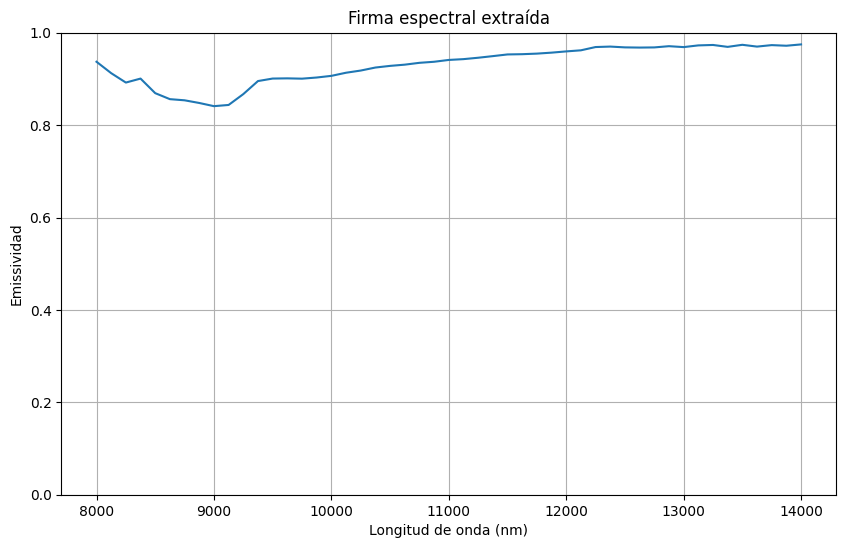

In [9]:
# Ejemplo de uso con el archivo de firma espectral
firma_path = r"C:\Users\mgefr\Documents\1UIS\proyecto-grado\assets\spectral_signatures\rock.igneous.alkalic.solid.all.ward17.jpl.nicolet.spectrum.txt"

firma_test = extract_spectral_values(wave_lengths, firma_path)

plt.figure(figsize=(10, 6))
plt.plot(wave_lengths, firma_test)
plt.ylim(0,1)
plt.title("Firma espectral extraída")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Emissividad")
plt.grid(True)
plt.show()


(49,)


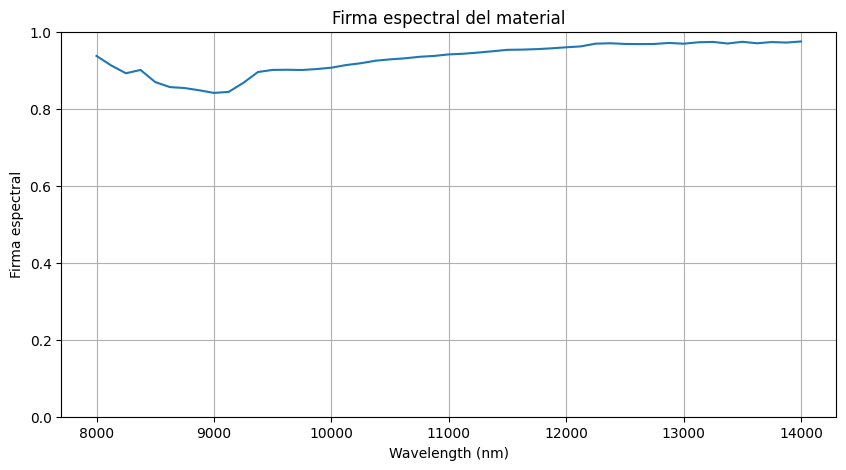

In [10]:
material = "stone"  # escoge el material que quieres
indice_material = np.where(dataBaseName == material)[0][
    0
]  # busca el indice del material en la base de datos

firma = dataBaseLib[:, indice_material]  # firma espectral del material

firma = extract_spectral_values(wave_lengths, firma_path)

print(firma.shape)

# plot
plt.figure(figsize=(10, 5))
plt.plot(wave_lengths, firma)
plt.title("Firma espectral del material")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Firma espectral")
plt.ylim(0, 1)
plt.grid()
plt.show()

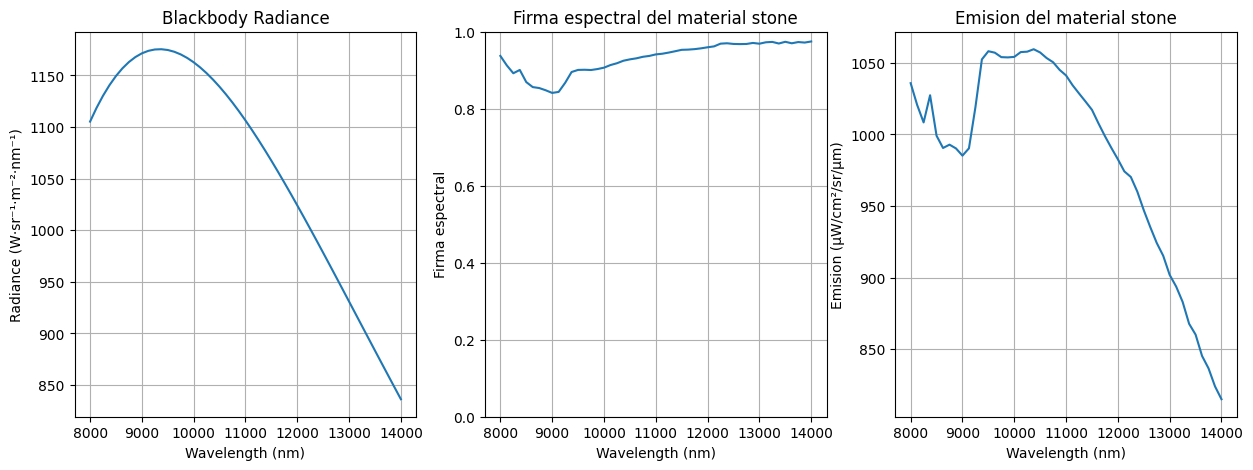

In [11]:
temperatura = 310.15  # temperatura objeto
temperatura_aire = 303.15

wave_lengths = np.linspace(8000, 14000, 49).astype(int)

black_body = blackbody_radiance_nm(wave_lengths, temperatura)  # radiancia del objeto
black_body_air = blackbody_radiance_nm(wave_lengths, temperatura_aire)  # radiancia del aire

emision = black_body * firma  # emision del objeto

# subplots
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(wave_lengths, black_body)
plt.title("Blackbody Radiance")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance (W·sr⁻¹·m⁻²·nm⁻¹)")
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(wave_lengths, firma)
plt.title(f"Firma espectral del material {material}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Firma espectral")
plt.ylim(0, 1)
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(wave_lengths, emision)
plt.title(f"Emision del material {material}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Emision (μW/cm²/sr/μm)")
plt.grid()

plt.show()


In [12]:
def lista_a_string(valores):
    return ", ".join(str(v) for v in valores)

In [13]:
dragon_emision = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(emision),
        },
    },
}

dragon_blackbody = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(black_body),
        },
    },
}

dragon_air = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(black_body_air),
        },
    },
}

## Derivación de la relación entre atenuación en dB y en forma exponencial natural

Partimos de la expresión en decibelios:

$$
10^{-\frac{a d}{10}}
$$

---

### Paso 1: Cambio de base
Usamos que $ 10^x = e^{x \ln 10} $:

$$
10^{-\frac{a d}{10}} 
= e^{\left(-\frac{a d}{10}\right)\ln 10}
= e^{-\left(\frac{\ln 10}{10}\,a\right) d}.
$$

---

### Paso 2: Comparación con la forma exponencial
La forma general en nepers es:

$$
e^{-a' d}.
$$

Al comparar:

$$
e^{-\left(\frac{\ln 10}{10}\,a\right) d} \equiv e^{-a' d},
$$

se obtiene:

$$
a' = \frac{\ln 10}{10}\,a.
$$

---

### Paso 3: Verificación por derivada
Si derivamos respecto a $d$:

$$
\frac{d}{dd}\left(10^{-\frac{a d}{10}}\right)
= \ln 10 \cdot 10^{-\frac{a d}{10}}\left(-\frac{a}{10}\right)
= -\left(\frac{\ln 10}{10}\,a\right) e^{-\left(\frac{\ln 10}{10}\,a\right)d}.
$$

Y la derivada de la forma natural:

$$
\frac{d}{dd}\left(e^{-a' d}\right) = -a' e^{-a'd}.
$$

Esto confirma que:

$$
a' = \frac{\ln 10}{10}\,a.
$$


In [14]:
def get_attenuation_for_wavelengths(wavelengths: np.ndarray, attenuation_file: str = "air") -> np.ndarray:

        wavelengths_um = wavelengths / 1000.0

        try:
            # Construir la ruta del archivo
            file_path = f"../assets/reference_data/{attenuation_file}.txt"
            
            # Cargar los datos del archivo
            trans_array = np.loadtxt(file_path)
            
            # Extraer columnas: [wavelength, transmittance, attenuation]
            file_wavelengths = trans_array[:, 0]  # Primera columna: longitudes de onda
            file_attenuation = trans_array[:, 2]  # Tercera columna: atenuación
            
            # Encontrar los índices más cercanos para cada longitud de onda deseada
            attenuation_values = []
            
            for target_wavelength in wavelengths_um:
                # Encontrar el índice del valor más cercano
                closest_index = np.argmin(np.abs(file_wavelengths - target_wavelength))
                attenuation_values.append(file_attenuation[closest_index])

            original = np.array(attenuation_values)
            
            attenuation_array = np.array(attenuation_values)

            attenuation_array = attenuation_array * (np.log(10) / 10)
            
            return [attenuation_array, original]

        except (OSError, ValueError) as e:
            raise RuntimeError("Error al obtener la atenuación") from e


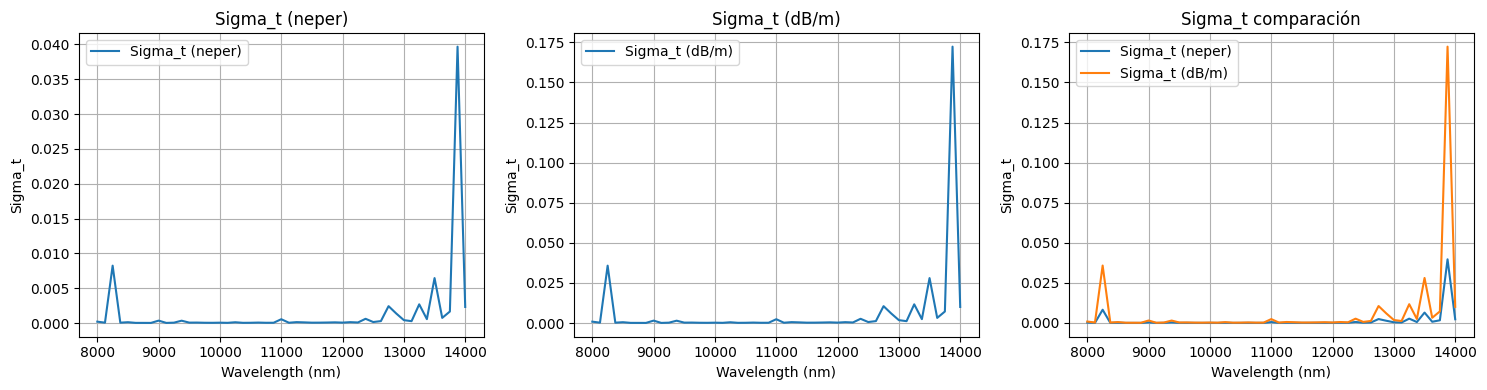

In [15]:
attenation_file = "air"
sigma_t, original_sigma_t = get_attenuation_for_wavelengths(wave_lengths, attenation_file)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(wave_lengths, sigma_t, label="Sigma_t (neper)")
plt.title("Sigma_t (neper)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Sigma_t")
plt.grid()
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(wave_lengths, original_sigma_t, label="Sigma_t (dB/m)")
plt.title("Sigma_t (dB/m)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Sigma_t")
plt.grid()
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(wave_lengths, sigma_t, label="Sigma_t (neper)")
plt.plot(wave_lengths, original_sigma_t, label="Sigma_t (dB/m)")
plt.title("Sigma_t comparación")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Sigma_t")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [16]:


niebla = {
    "type": "homogeneous",  # medio homogeneo, es decir el mismo sigma en todo el espacio,
    "id": "niebla",  # identificador del medio, para referenciarlo
    "albedo": {
        "type": "constvolume",  # textura volumétrica constante
        "value": {"type": "uniform", "value": 0.0},
    },
    "sigma_t": {
        "type": "constvolume",
        "value": {
            "type": "irregular",  # definimos un espectro
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(sigma_t),
        },
    },
    "phase": {  # define como se dispersa la luz en el medio (no la he entendido bien)
        "type": "hg",
        "g": 0.95,  # usar valores de 0.9-0.95 que es lo que pasa en el infrarrojo lejano, preguntarle al profe
        # con este nuevo valor pareciera que no existiera niebla, pero si lo pongo en 0.0 se ve la niebla
    },
}

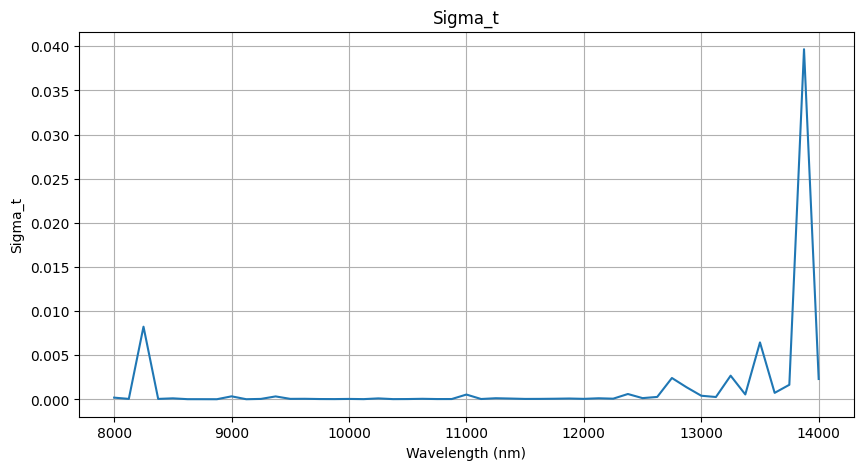

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(wave_lengths, sigma_t)
plt.title("Sigma_t")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Sigma_t")
plt.grid()
plt.show()

In [18]:
sensor_espectral_niebla = load_sensor_spectral(r, phi, theta, wave_lengths, sigma, k, n)
sensor_espectral_niebla["medium"] = {"type": "ref", "id": "niebla"}

sensor_espectral_sin_niebla = load_sensor_spectral(
    r, phi, theta, wave_lengths, sigma, k, n
)

sensor_depth = load_sensor_depth(r, phi, theta)

In [19]:
integrador_niebla = {"type": "volpathmis", "max_depth": 8}

integrador_sin_niebla = {"type": "path"}



In [20]:
scene_sin_niebla = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_sin_niebla,
        "sensor": sensor_espectral_sin_niebla,
        "dragon": dragon_emision,
    }
)

scene_niebla = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_niebla,
        "niebla": niebla,
        "sensor": sensor_espectral_niebla,
        "dragon": dragon_emision,
    }
)
scene_depth = mi.load_dict(
    {
        "type": "scene",
        "integrator": {
            "type": "depth",
        },
        "sensor": sensor_depth,
        "dragon": dragon_emision,
    }
)

In [21]:
imagen_niebla = mi.render(scene_niebla, spp=spp)
imagen_sin_niebla = mi.render(scene_sin_niebla, spp=spp)
imagen_depth = mi.render(scene_depth, spp=spp)

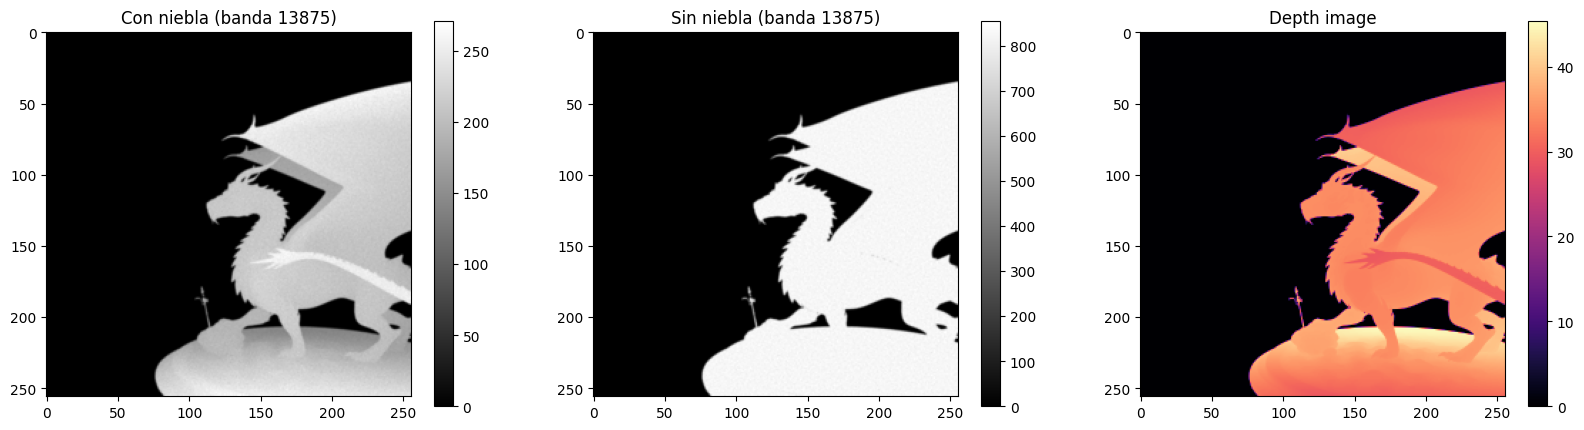

In [22]:
banda = 47
min_value = np.min(imagen_niebla[:, :, banda])
max_value = np.max(imagen_niebla[:, :, banda])

plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.imshow(imagen_niebla[:, :, banda], cmap="gray", vmin=0, vmax=max_value)
plt.colorbar()
plt.title("Con niebla (banda {})".format(wave_lengths[banda]))

plt.subplot(1, 3, 2)
plt.imshow(imagen_sin_niebla[:, :, banda], cmap="gray", vmin=0)
plt.colorbar()
plt.title("Sin niebla (banda {})".format(wave_lengths[banda]))

plt.subplot(1, 3, 3)
plt.imshow(imagen_depth, cmap="magma")
plt.title("Depth image")
plt.colorbar()

plt.show()


Distancia al objeto (pixel): [31.225897]


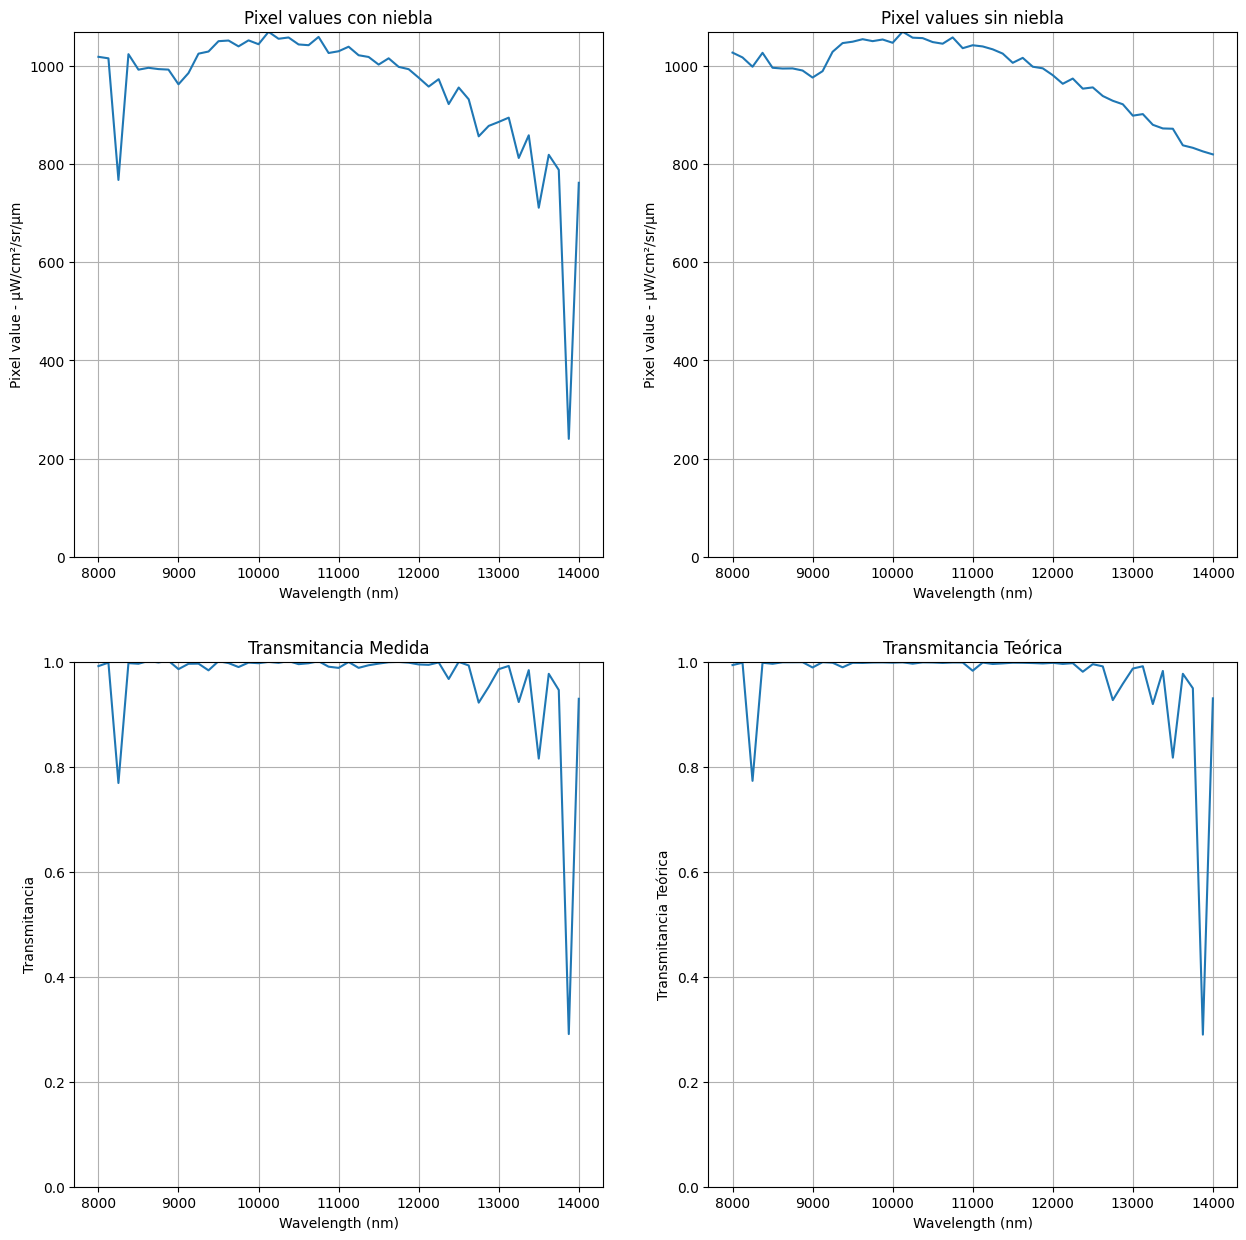

In [23]:
x = 200
y = 250

pixel_niebla = imagen_niebla[y, x, :].numpy()
pixel_sin_niebla = imagen_sin_niebla[y, x, :].numpy()
ditancia = imagen_depth[y, x].numpy()

print("Distancia al objeto (pixel):", ditancia)

transmitancia_medicion = pixel_niebla / pixel_sin_niebla
transmitancia_teorica = np.exp(-np.array(sigma_t) * ditancia)

pixel_max = np.max(pixel_sin_niebla)

plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.plot(wave_lengths, pixel_niebla)
plt.title("Pixel values con niebla")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Pixel value - μW/cm²/sr/μm")
plt.ylim(0, pixel_max)
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(wave_lengths, pixel_sin_niebla)
plt.title("Pixel values sin niebla")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Pixel value - μW/cm²/sr/μm")
plt.ylim(0, pixel_max)
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(wave_lengths, transmitancia_medicion)
plt.title("Transmitancia Medida")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmitancia")
plt.ylim(0, 1)
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(wave_lengths, transmitancia_teorica)
plt.title("Transmitancia Teórica")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmitancia Teórica")
plt.ylim(0, 1)
plt.grid()

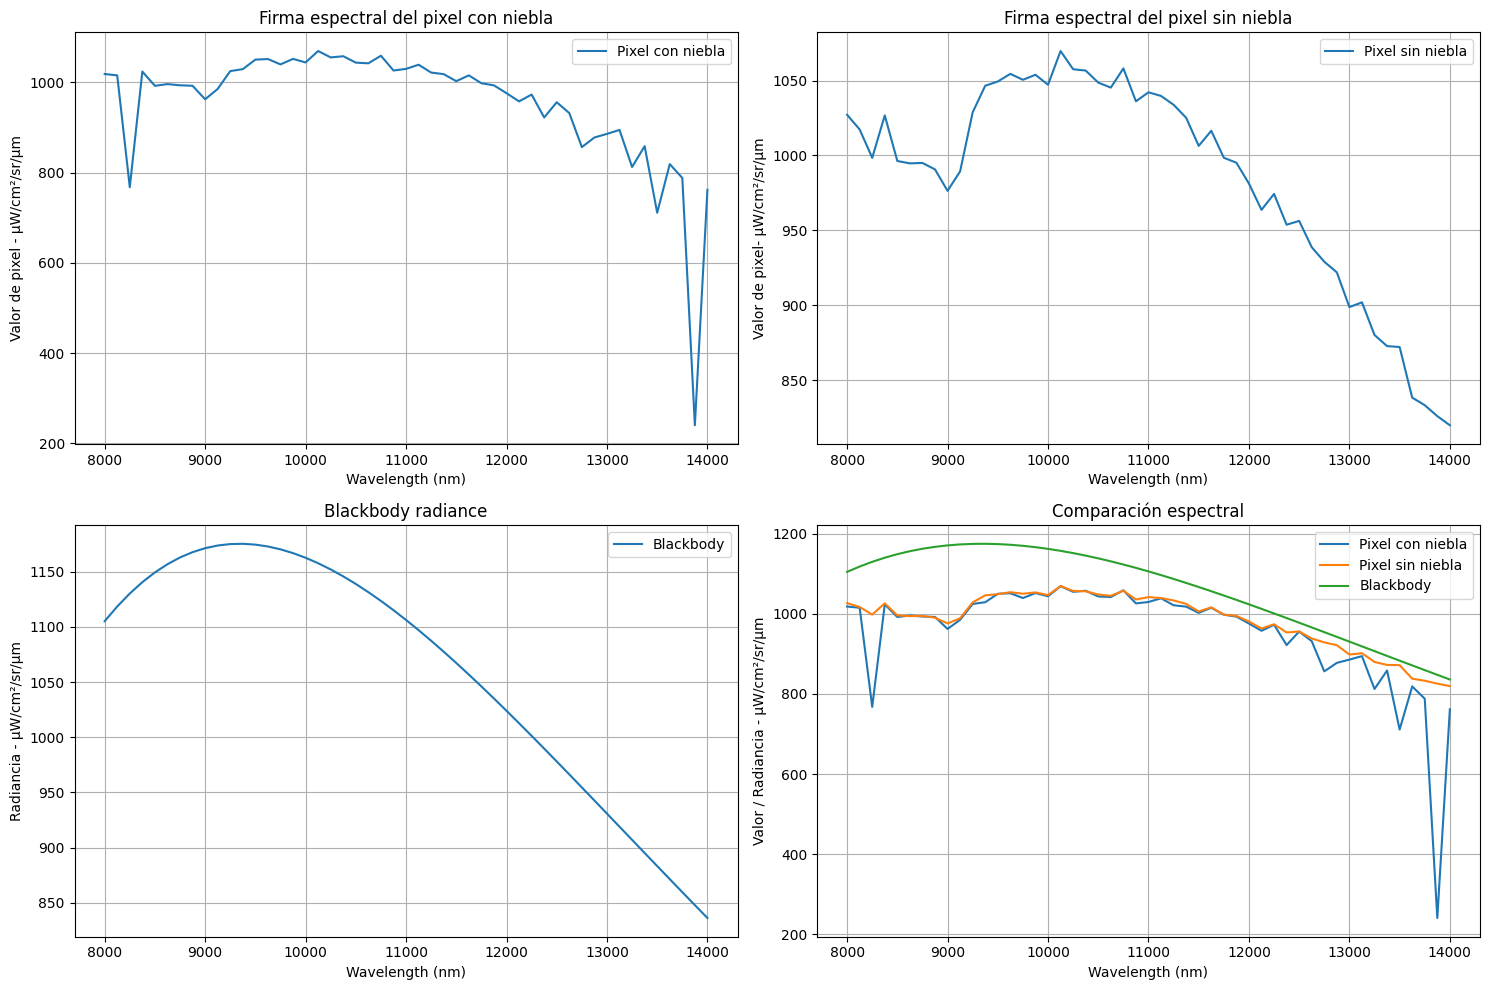

In [24]:
plt.figure(figsize=(15, 10))

# 1. Pixel con niebla
plt.subplot(2, 2, 1)
plt.plot(wave_lengths, pixel_niebla, label="Pixel con niebla")
plt.title("Firma espectral del pixel con niebla")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.grid()
plt.legend()

# 2. Pixel sin niebla
plt.subplot(2, 2, 2)
plt.plot(wave_lengths, pixel_sin_niebla, label="Pixel sin niebla")
plt.title("Firma espectral del pixel sin niebla")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel- μW/cm²/sr/μm")
plt.grid()
plt.legend()

# 3. Blackbody
plt.subplot(2, 2, 3)
plt.plot(wave_lengths, black_body, label="Blackbody")
plt.title("Blackbody radiance")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiancia - μW/cm²/sr/μm")
plt.grid()
plt.legend()

# 4. Todas juntas
plt.subplot(2, 2, 4)
plt.plot(wave_lengths, pixel_niebla, label="Pixel con niebla")
plt.plot(wave_lengths, pixel_sin_niebla, label="Pixel sin niebla")
plt.plot(wave_lengths, black_body, label="Blackbody")
plt.title("Comparación espectral")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor / Radiancia - μW/cm²/sr/μm")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

## Test black body air emitter

In [25]:
scene_emision_aire_test = mi.load_dict({
    "type": "scene",
    "integrator": integrador_sin_niebla,
    "sensor": sensor_espectral_sin_niebla,
    "emitter": {
        "type": "constant",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(black_body_air),
        },
    },
})

In [26]:
test_air = mi.render(scene_emision_aire_test, spp=spp)

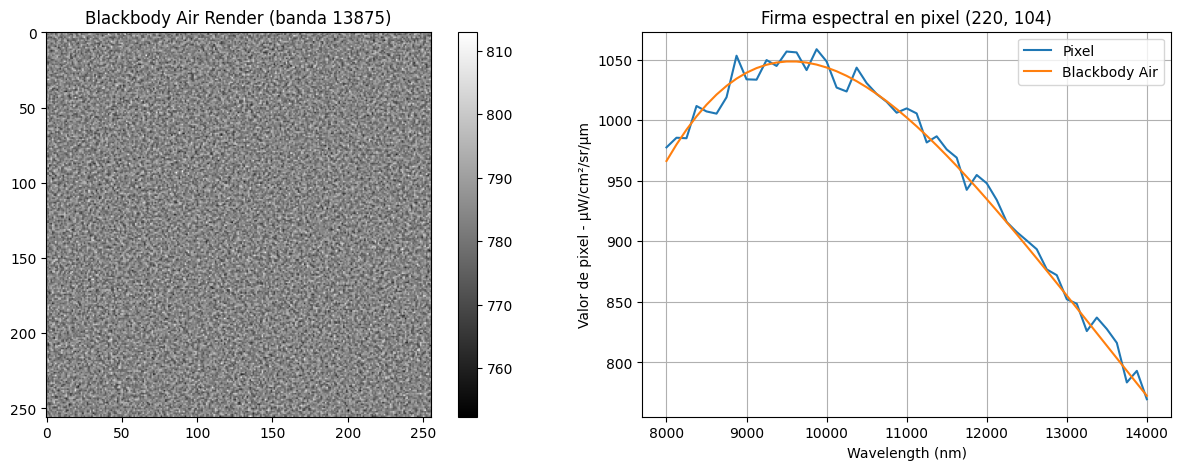

In [27]:
plt.figure(figsize=(15, 5))
banda = 47
plt.subplot(1, 2, 1)
plt.imshow(test_air[:, :, banda], cmap="gray")
plt.title(f"Blackbody Air Render (banda {wave_lengths[banda]})")
plt.colorbar()

# Seleccionar un punto aleatorio dentro de la imagen
height, width, _ = test_air.shape
rand_y = np.random.randint(0, height)
rand_x = np.random.randint(0, width)

# Extraer la firma espectral del pixel aleatorio
firma_pixel_air = test_air[rand_y, rand_x, :].numpy()

# Graficar la firma espectral del pixel seleccionado
plt.subplot(1, 2, 2)
plt.plot(wave_lengths, firma_pixel_air, label="Pixel")
plt.plot(wave_lengths, black_body_air, label="Blackbody Air")
plt.title(f"Firma espectral en pixel ({rand_x}, {rand_y})")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.grid()
plt.legend()
plt.show()

## black body air

In [28]:
# Crear un cubo grande usando Mitsuba y el sensor espectral existente
cubo_grande = {
    "type": "cube",
    "to_world": T().scale([10, 10, 10]).translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(black_body_air),
        },
    },
}

scene_cubo_grande = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_sin_niebla,
        "sensor": sensor_espectral_sin_niebla,
        "cubo": cubo_grande,
    }
)

In [29]:
#black_body_air_render = mi.render(scene_cubo_grande, spp=spp)
black_body_air_render = mi.render(scene_emision_aire_test, spp=spp)

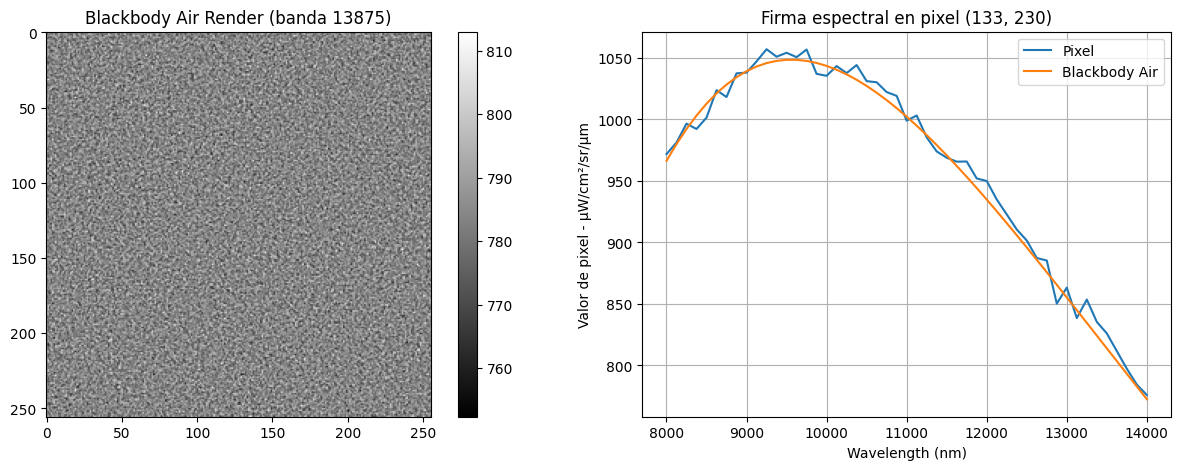

In [30]:
# Mostrar la imagen renderizada del black body air (escena cubo grande)
plt.figure(figsize=(15, 5))
banda = 47
plt.subplot(1, 2, 1)
plt.imshow(black_body_air_render[:, :, banda], cmap="gray")
plt.title(f"Blackbody Air Render (banda {wave_lengths[banda]})")
plt.colorbar()

# Seleccionar un punto aleatorio dentro de la imagen
height, width, _ = black_body_air_render.shape
rand_y = np.random.randint(0, height)
rand_x = np.random.randint(0, width)

# Extraer la firma espectral del pixel aleatorio
firma_pixel_air = black_body_air_render[rand_y, rand_x, :].numpy()

# Graficar la firma espectral del pixel seleccionado
plt.subplot(1, 2, 2)
plt.plot(wave_lengths, firma_pixel_air, label="Pixel")
plt.plot(wave_lengths, black_body_air, label="Blackbody Air")
plt.title(f"Firma espectral en pixel ({rand_x}, {rand_y})")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.grid()
plt.legend()
plt.show()

# Prueba #1

In [31]:
banda = 47
x = 200
y = 250

## L_obj = T * e * B

In [32]:
imagen_niebla = mi.render(scene_niebla, spp=spp)
imagen_sin_niebla = mi.render(scene_sin_niebla, spp=spp)
imagen_depth = mi.render(scene_depth, spp=spp)

(49,)


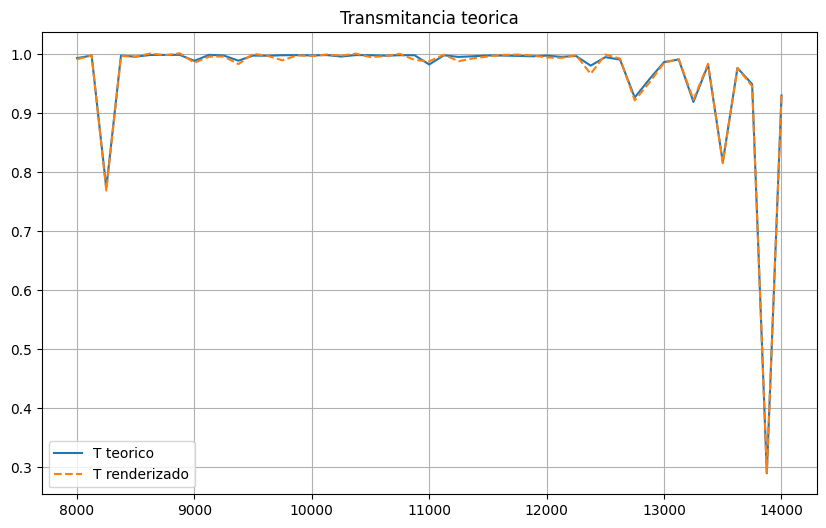

In [33]:
T_renderizado = (imagen_niebla/imagen_sin_niebla)[y,x,:].numpy()
print(T_renderizado.shape)

distances = imagen_depth[y,x].numpy()
#T_teorico = np.exp(-np.array(sigma_t)*distances)
T_teorico = np.exp(-sigma_t*distances)

plt.figure(figsize=(10, 6))
plt.plot(wave_lengths, T_teorico, label = "T teorico")
plt.plot(wave_lengths, T_renderizado, label = "T renderizado", linestyle='dashed')
plt.title("Transmitancia teorica")
plt.legend()
plt.grid()

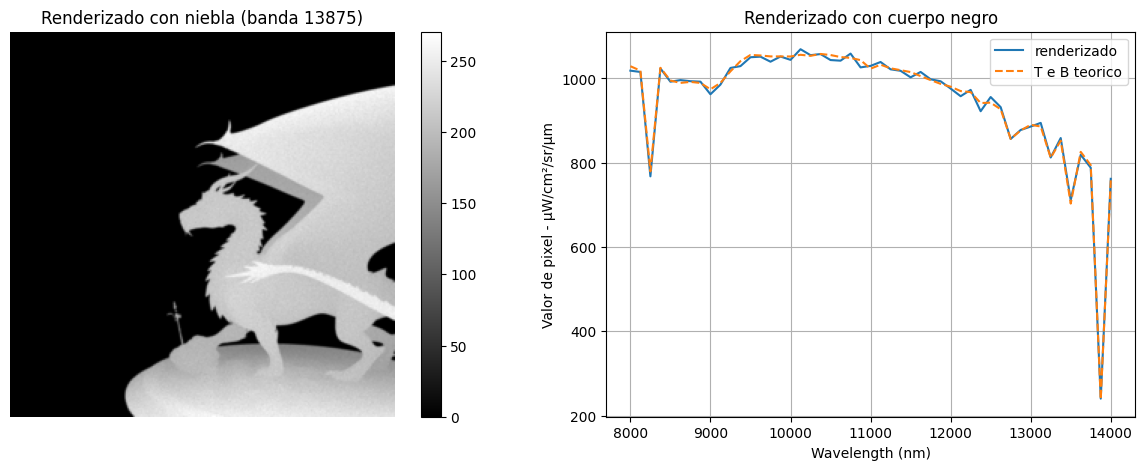

In [34]:
T_e_B_teorico = T_teorico * emision

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(imagen_niebla[:, :, banda], cmap="gray")
plt.title("Renderizado con niebla (banda " + str(wave_lengths[banda]) + ")")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 2, 2)
plt.plot(wave_lengths, imagen_niebla[y,x,:].numpy(), label = "renderizado")
plt.plot(wave_lengths, T_e_B_teorico, label = "T e B teorico", linestyle='dashed')
plt.title("Renderizado con cuerpo negro")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.legend()
plt.grid()


## B_air

In [35]:
black_body_air_render = mi.render(scene_emision_aire_test, spp=spp)

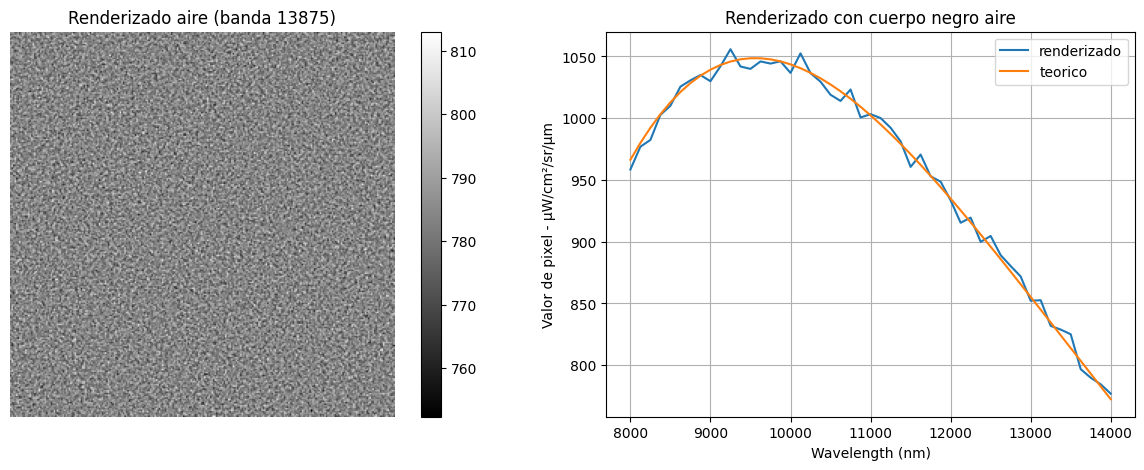

In [36]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(black_body_air_render[:, :, banda], cmap="gray")
plt.title("Renderizado aire (banda " + str(wave_lengths[banda]) + ")")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 2, 2)
plt.plot(wave_lengths, black_body_air_render[y,x,:].numpy(), label = "renderizado")
plt.plot(wave_lengths, black_body_air, label = "teorico")
plt.title("Renderizado con cuerpo negro aire")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.legend()
plt.grid()



## T * B

In [37]:
scene_air_obj_render = scene_niebla = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_niebla,
        "niebla": niebla,
        "sensor": sensor_espectral_niebla,
        "dragon": dragon_air,
    }
)

In [38]:
T_B = mi.render(scene_air_obj_render, spp=spp)

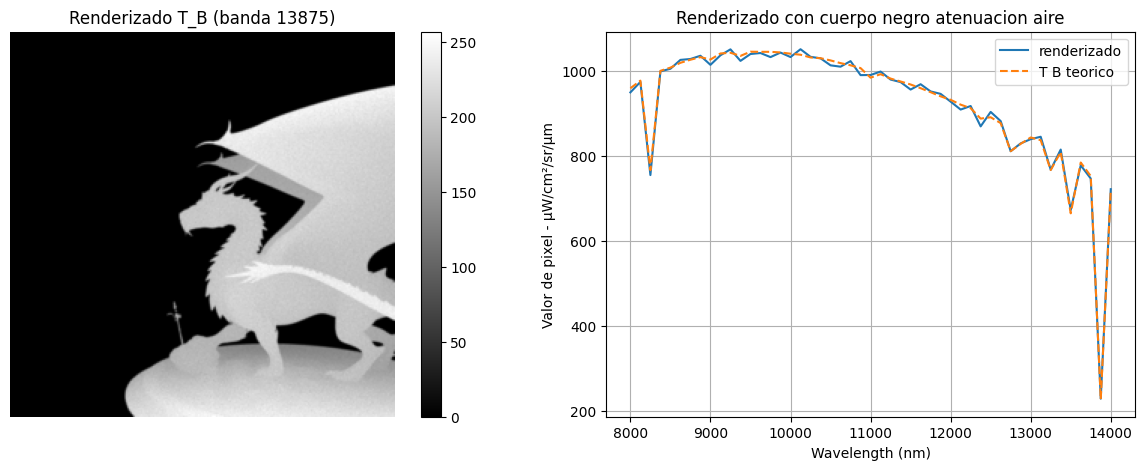

In [39]:
T_B_teorico = T_teorico * black_body_air

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(T_B[:, :, banda], cmap="gray")
plt.title("Renderizado T_B (banda " + str(wave_lengths[banda]) + ")")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 2, 2)
plt.plot(wave_lengths, T_B[y,x,:].numpy(), label = "renderizado")
plt.plot(wave_lengths, T_B_teorico, label = "T B teorico", linestyle='dashed')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.title("Renderizado con cuerpo negro atenuacion aire")
plt.legend()
plt.grid()



# B_air - T * B_air

In [40]:
B_T_B = black_body_air_render - T_B

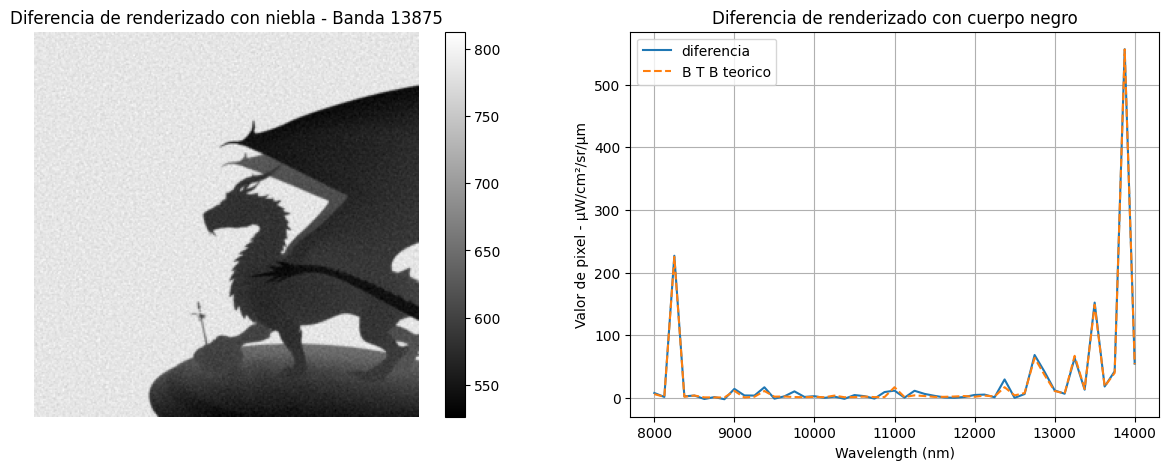

In [41]:
B_T_B_teorico = black_body_air - T_B_teorico

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
#plt.imshow(B_T_B[:, :, banda], cmap="gray")
plt.imshow(B_T_B[:, :, banda], cmap="gray")
plt.title("Diferencia de renderizado con niebla - Banda " + str(wave_lengths[banda]))
plt.colorbar()
plt.axis("off")

plt.subplot(1, 2, 2)
plt.plot(wave_lengths, B_T_B[y,x,:].numpy(), label = "diferencia")
plt.plot(wave_lengths, B_T_B_teorico, label = "B T B teorico", linestyle='dashed')
plt.title("Diferencia de renderizado con cuerpo negro")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.legend()
plt.grid()


## Juntamos todo

In [42]:
resultado_1 = imagen_niebla + B_T_B

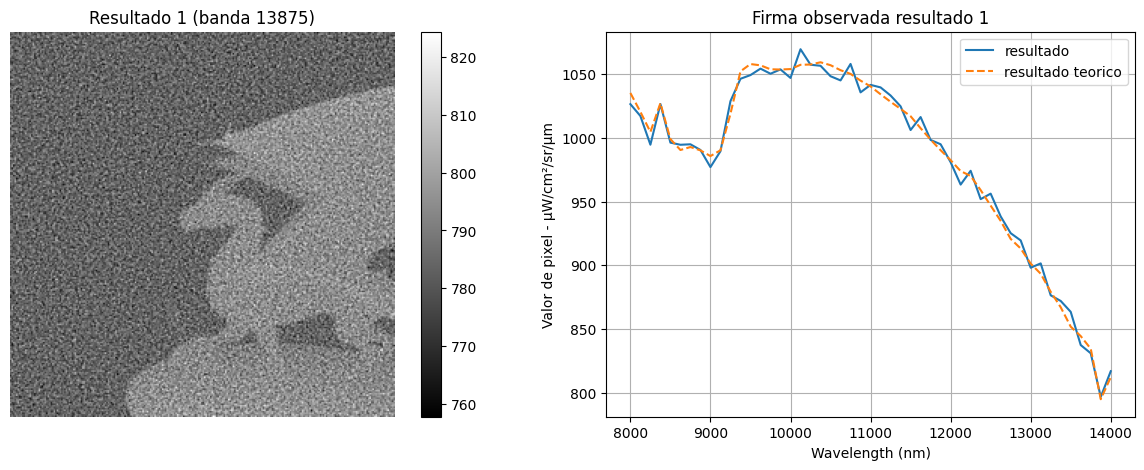

In [43]:
resultado_1_teorico = T_e_B_teorico + B_T_B_teorico

plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
plt.imshow(resultado_1[:, :, banda], cmap="gray")
plt.title("Resultado 1 (banda {})".format(wave_lengths[banda]))
plt.colorbar()
plt.axis("off")

plt.subplot(1,2,2)
plt.plot(wave_lengths, resultado_1[y,x,:].numpy(), label = "resultado")
plt.plot(wave_lengths, resultado_1_teorico, label = "resultado teorico", linestyle='dashed')
plt.title("Firma observada resultado 1")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.legend()
plt.grid()


## Graficamos

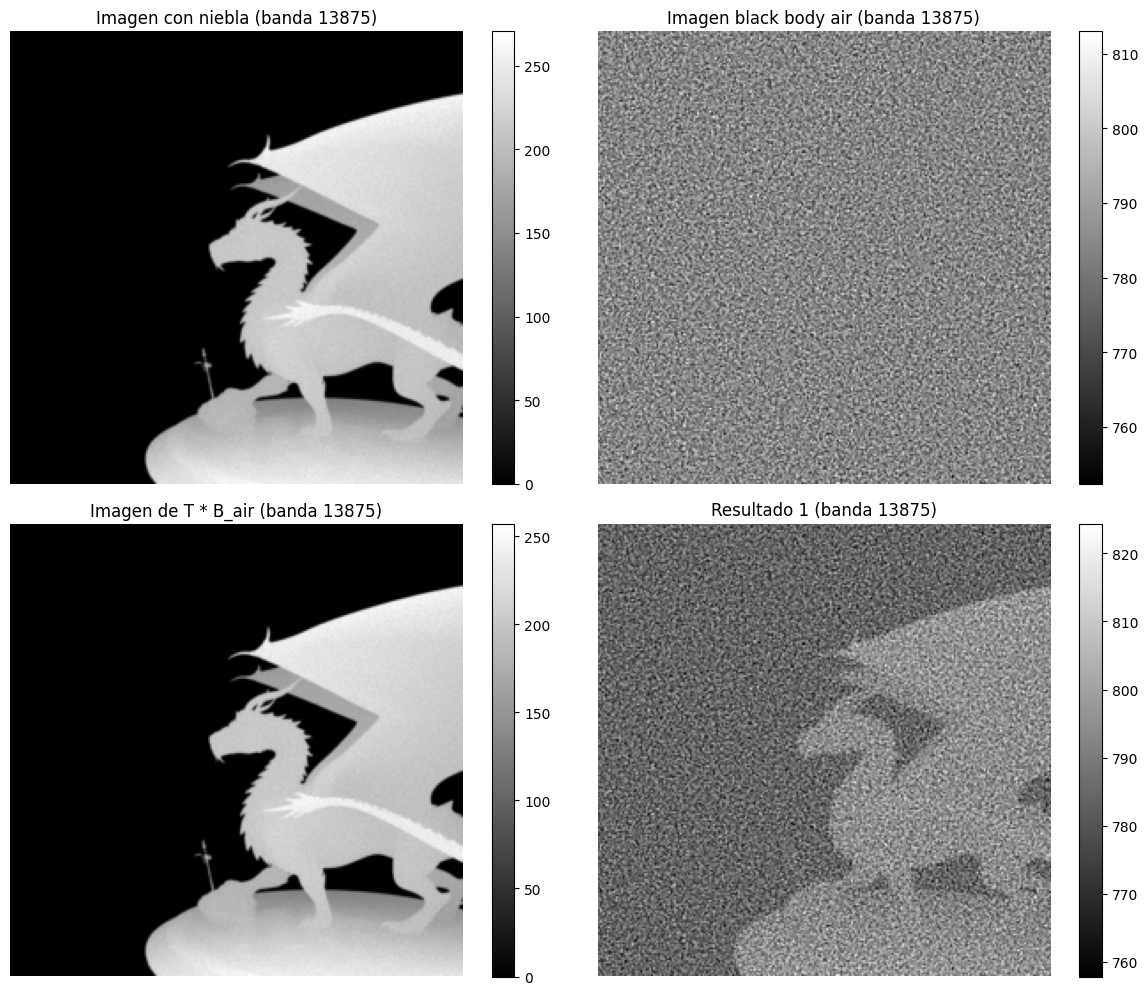

In [44]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(imagen_niebla[:, :, banda], cmap="gray")
plt.title("Imagen con niebla (banda {})".format(wave_lengths[banda]))
plt.colorbar()
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(black_body_air_render[:, :, banda], cmap="gray")
plt.title("Imagen black body air (banda {})".format(wave_lengths[banda]))
plt.colorbar()
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(T_B[:, :, banda], cmap="gray")
plt.title("Imagen de T * B_air (banda {})".format(wave_lengths[banda]))
plt.colorbar()
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(resultado_1[:, :, banda], cmap="gray")
plt.title("Resultado 1 (banda {})".format(wave_lengths[banda]))
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()


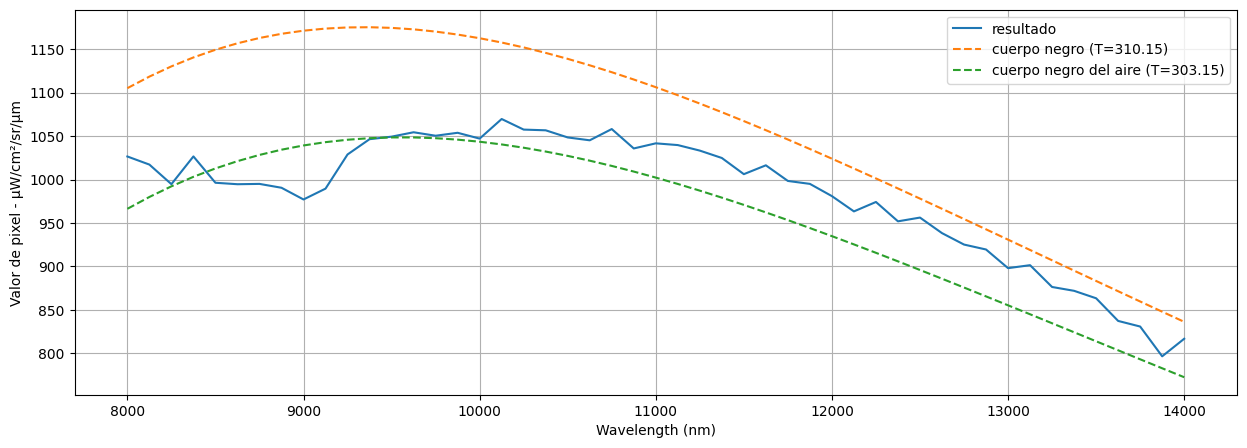

In [45]:
plt.figure(figsize=(15, 5))
plt.plot(wave_lengths, resultado_1[y,x,:].numpy(), label = "resultado")
plt.plot(wave_lengths, black_body, label = "cuerpo negro (T={})".format(temperatura), linestyle='dashed')
plt.plot(wave_lengths, black_body_air, label = "cuerpo negro del aire (T={})".format(temperatura_aire), linestyle='dashed')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.grid()
plt.legend()
plt.show()

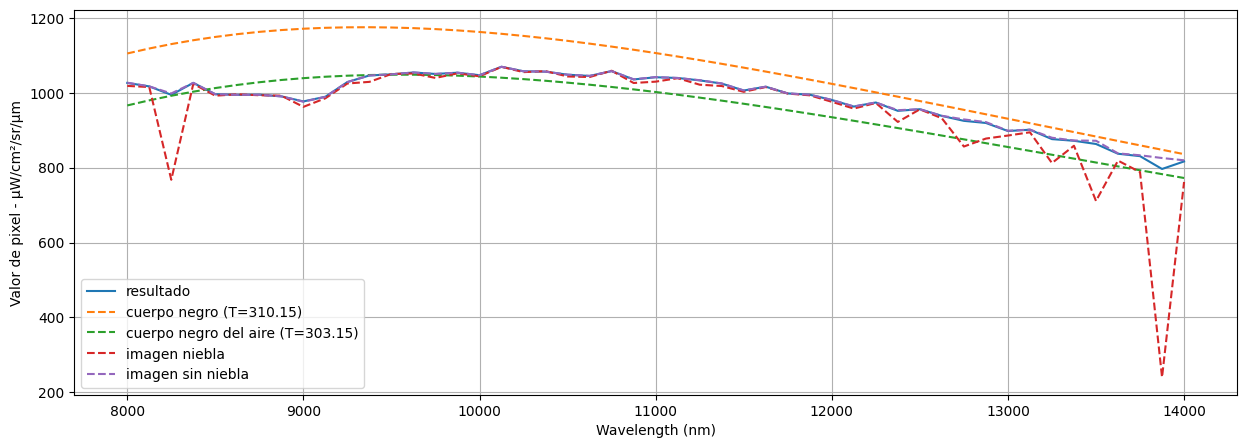

In [46]:
plt.figure(figsize=(15, 5))
plt.plot(wave_lengths, resultado_1[y,x,:].numpy(), label = "resultado")
plt.plot(wave_lengths, black_body, label = "cuerpo negro (T={})".format(temperatura), linestyle='dashed')
plt.plot(wave_lengths, black_body_air, label = "cuerpo negro del aire (T={})".format(temperatura_aire), linestyle='dashed')
plt.plot(wave_lengths, imagen_niebla[y,x,:].numpy(), label = "imagen niebla", linestyle='dashed')
plt.plot(wave_lengths, imagen_sin_niebla[y,x,:].numpy(), label = "imagen sin niebla", linestyle='dashed')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.grid()
plt.legend()
plt.show()

# Prueba 2

## T * (e * B_obj - B_air)

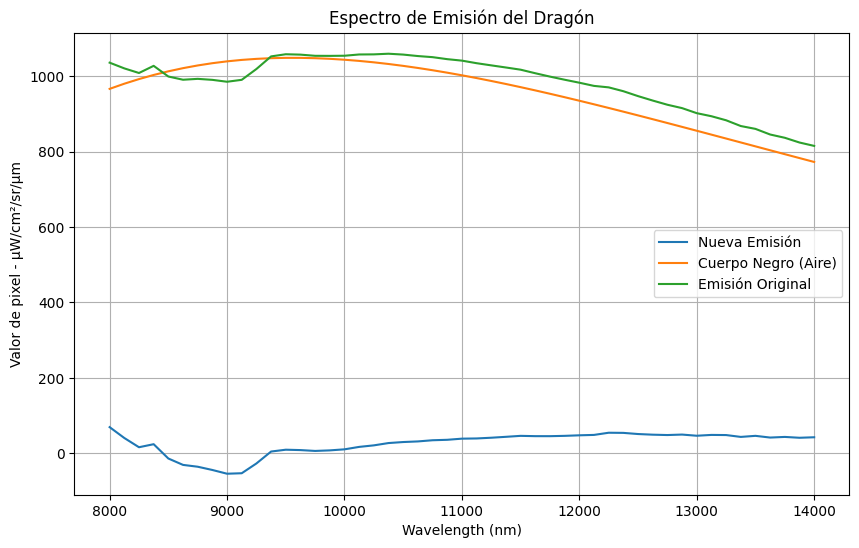

In [47]:
new_emision = emision - black_body_air

plt.figure(figsize=(10, 6))
plt.plot(wave_lengths, new_emision, label="Nueva Emisión")
plt.plot(wave_lengths, black_body_air, label="Cuerpo Negro (Aire)")
plt.plot(wave_lengths, emision, label="Emisión Original")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.title("Espectro de Emisión del Dragón")
plt.legend()
plt.grid()
plt.show()

In [48]:
dragon__new_emision = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(new_emision),
        },
    },
}

new_scene_niebla = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_niebla,
        "niebla": niebla,
        "sensor": sensor_espectral_niebla,
        "dragon": dragon__new_emision,
    }
)

RuntimeError: [parser.cpp:1708] At dictionary node "dragon.emitter.radiance": failed to instantiate texture plugin of type "irregular": [distr_1d.h:956] IrregularContinuousDistribution: entries must be non-negative!

In [ ]:
T_eBobj_Bair = mi.render(new_scene_niebla, spp=spp)

In [ ]:
T_eBobj_Bair_teorico = T_teorico * (emision - black_body_air)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(T_eBobj_Bair[:,:, banda], cmap = "gray")
plt.title("Renderizado T_eBobj - Bair (banda {})".format(wave_lengths[banda]))
plt.colorbar()

plt.subplot(1, 2, 2)
plt.plot(wave_lengths, T_eBobj_Bair[y,x,:].numpy(), label="renderizado")
plt.plot(wave_lengths, T_eBobj_Bair_teorico, label="teórico")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.legend()
plt.grid()
plt.show()

## Resultado 2

In [ ]:
resultado_2 = T_eBobj_Bair + black_body_air_render

In [ ]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(resultado_1[:,:, banda], cmap = "gray")
plt.title("Resultado 1 banda {}".format(wave_lengths[banda]))
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(resultado_2[:,:, banda], cmap = "gray")
plt.title("Resultado 2 banda {}".format(wave_lengths[banda]))
plt.colorbar()
plt.show()

In [ ]:
rmse = np.sqrt(np.mean((resultado_2 - resultado_1)**2))

print("RMSE:", rmse)

In [ ]:
resultado_2_teorico = T_eBobj_Bair_teorico + black_body_air

plt.figure(figsize=(15, 5))
plt.plot(wave_lengths, resultado_2_teorico, label="Resultado 2 Teórico")
plt.plot(wave_lengths, resultado_1_teorico, label="Resultado 1 Teorico")
plt.plot(wave_lengths, resultado_1[y,x,:].numpy(), label="Resultado 1")
plt.plot(wave_lengths, resultado_2[y,x,:].numpy(), label="Resultado 2")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.legend()
plt.grid()
plt.show()

## Test final

In [ ]:
scene_niebla_emitter = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_niebla,
        "niebla": niebla,
        "sensor": sensor_espectral_niebla,
        "dragon": dragon_emision,
        "emitter": {
        "type": "constant",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(black_body_air),
        },
    },
    }
)

In [ ]:
niebla_emitter_render = mi.render(scene_niebla_emitter, spp=spp)

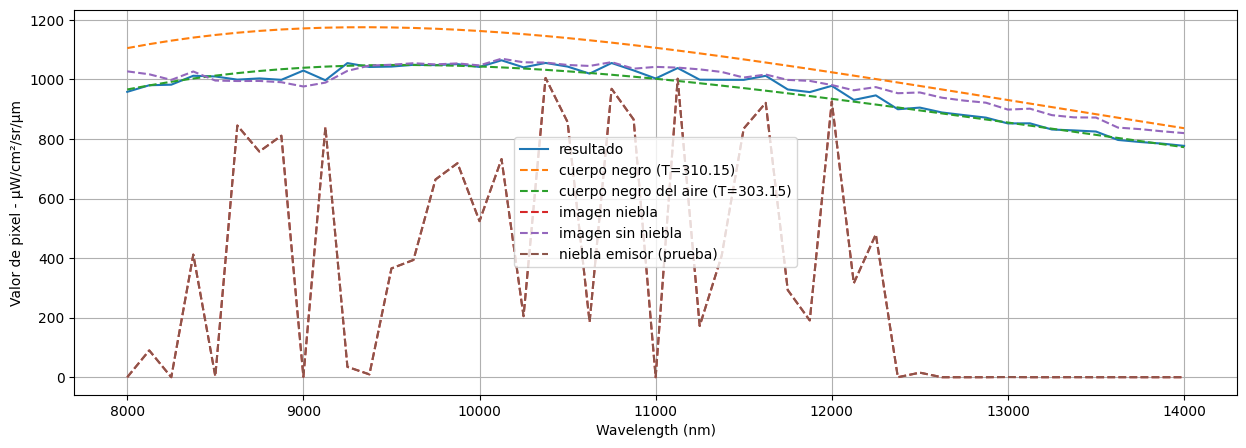

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(wave_lengths, resultado_1[y,x,:].numpy(), label = "resultado")
plt.plot(wave_lengths, black_body, label = "cuerpo negro (T={})".format(temperatura), linestyle='dashed')
plt.plot(wave_lengths, black_body_air, label = "cuerpo negro del aire (T={})".format(temperatura_aire), linestyle='dashed')
plt.plot(wave_lengths, imagen_niebla[y,x,:].numpy(), label = "imagen niebla", linestyle='dashed')
plt.plot(wave_lengths, imagen_sin_niebla[y,x,:].numpy(), label = "imagen sin niebla", linestyle='dashed')
plt.plot(wave_lengths, niebla_emitter_render[y,x,:].numpy(), label = "niebla emisor (prueba)", linestyle='dashed')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.grid()
plt.legend()
plt.show()

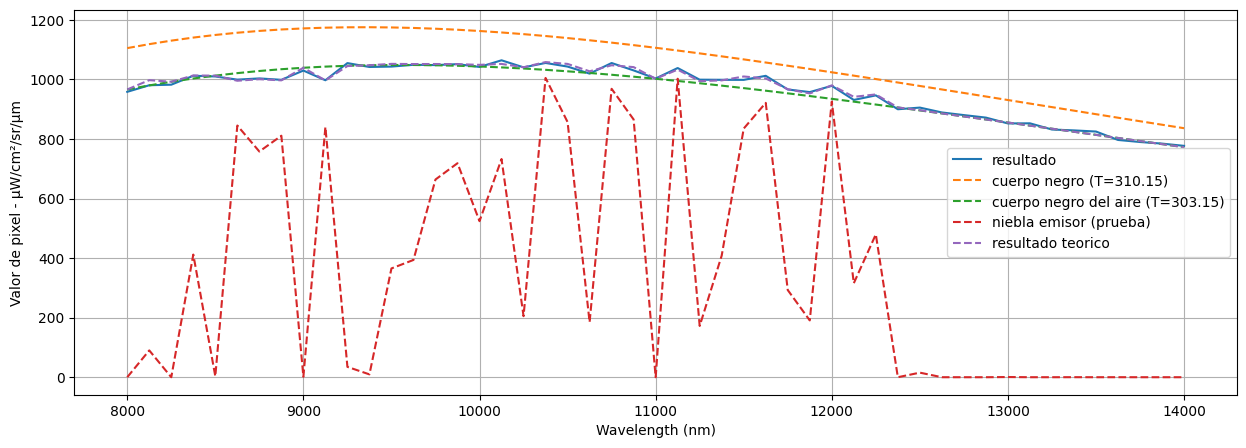

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(wave_lengths, resultado_1[y,x,:].numpy(), label = "resultado")
plt.plot(wave_lengths, black_body, label = "cuerpo negro (T={})".format(temperatura), linestyle='dashed')
plt.plot(wave_lengths, black_body_air, label = "cuerpo negro del aire (T={})".format(temperatura_aire), linestyle='dashed')
plt.plot(wave_lengths, niebla_emitter_render[y,x,:].numpy(), label = "niebla emisor (prueba)", linestyle='dashed')
plt.plot(wave_lengths, resultado_1_teorico, label = "resultado teorico", linestyle='dashed')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.grid()
plt.legend()
plt.show()

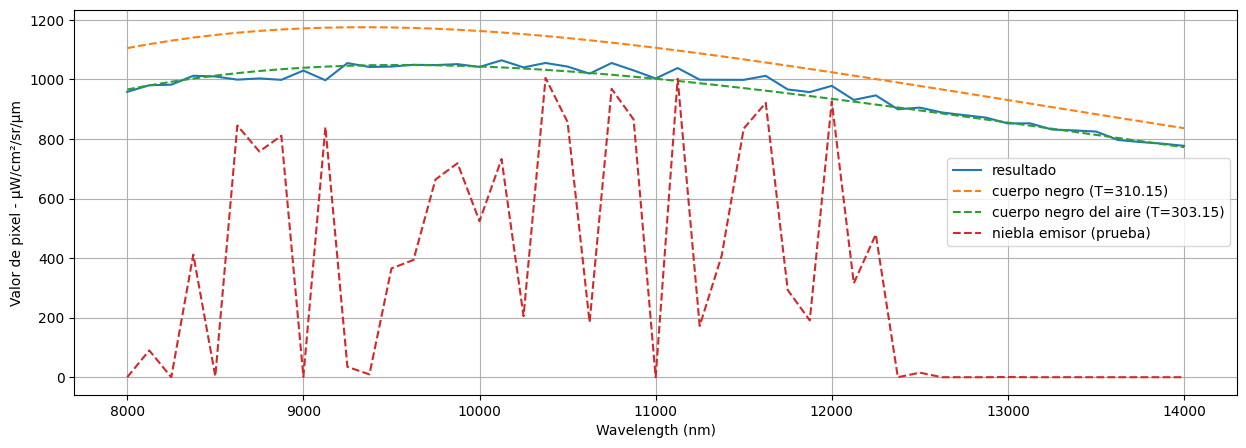

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(wave_lengths, resultado_1[y,x,:].numpy(), label = "resultado")
plt.plot(wave_lengths, black_body, label = "cuerpo negro (T={})".format(temperatura), linestyle='dashed')
plt.plot(wave_lengths, black_body_air, label = "cuerpo negro del aire (T={})".format(temperatura_aire), linestyle='dashed')
plt.plot(wave_lengths, niebla_emitter_render[y,x,:].numpy(), label = "niebla emisor (prueba)", linestyle='dashed')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.grid()
plt.legend()
plt.show()

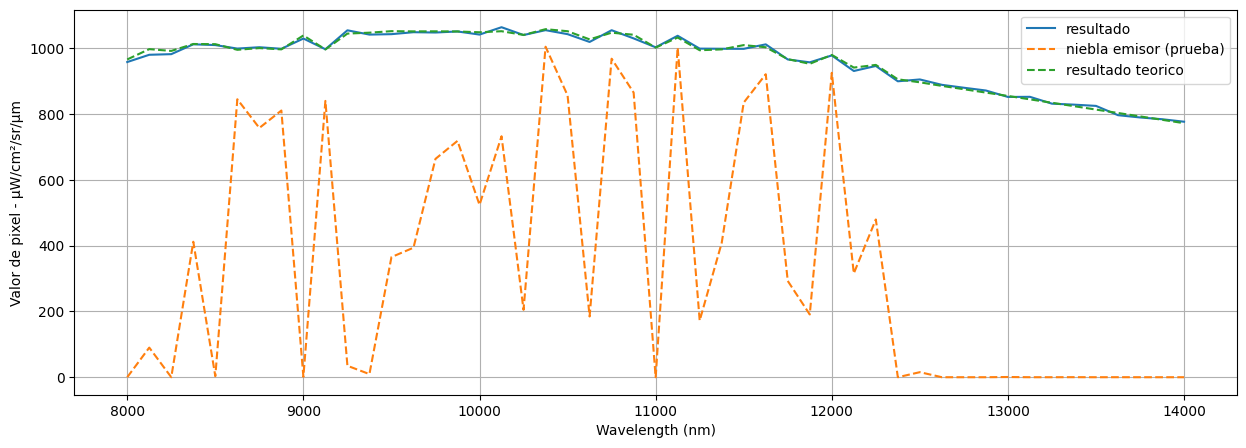

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(wave_lengths, resultado_1[y,x,:].numpy(), label = "resultado")
#plt.plot(wave_lengths, black_body, label = "cuerpo negro (T={})".format(temperatura), linestyle='dashed')
#plt.plot(wave_lengths, black_body_air, label = "cuerpo negro del aire (T={})".format(temperatura_aire), linestyle='dashed')
plt.plot(wave_lengths, niebla_emitter_render[y,x,:].numpy(), label = "niebla emisor (prueba)", linestyle='dashed')
plt.plot(wave_lengths, resultado_1_teorico, label = "resultado teorico", linestyle='dashed')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.grid()
plt.legend()
plt.show()

## Prueba de teorico x2

In [ ]:
distances = imagen_depth[y,x].numpy()
T_teorico = np.exp(-sigma_t*distances)
L_obj = T_teorico*emision
L_air = (1 - T_teorico)*black_body_air
L_obs = L_obj + L_air

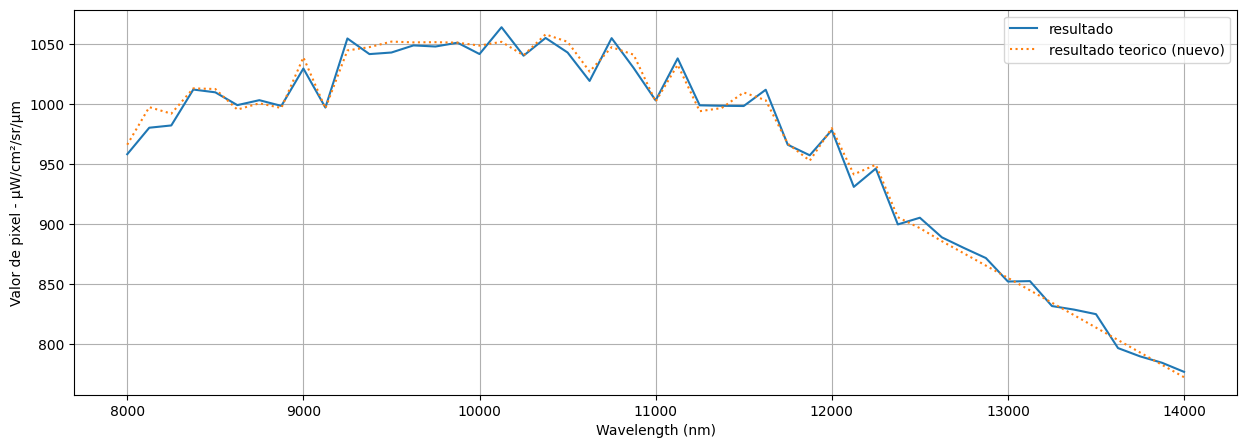

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(wave_lengths, resultado_1[y,x,:].numpy(), label = "resultado")
#plt.plot(wave_lengths, black_body, label = "cuerpo negro (T={})".format(temperatura), linestyle='dashed')
#plt.plot(wave_lengths, black_body_air, label = "cuerpo negro del aire (T={})".format(temperatura_aire), linestyle='dashed')
#plt.plot(wave_lengths, niebla_emitter_render[y,x,:].numpy(), label = "niebla emisor (prueba)", linestyle='dashed')
#plt.plot(wave_lengths, resultado_1_teorico, label = "resultado teorico", linestyle='dashed')
plt.plot(wave_lengths, L_obs, label = "resultado teorico (nuevo)", linestyle='dotted')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Valor de pixel - μW/cm²/sr/μm")
plt.grid()
plt.legend()
plt.show()

# Prueba de valores y firmas

In [ ]:
T_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
E_values = [0.0, 0.5, 0.8, 0.9, 0.95, 1.0]
B_obj = [600, 800, 1000, 1200, 1400]
B_air = 1000

print(f"{'T':>4} {'E':>4} {'B_obj':>6} {'L_obj':>10} {'L_air':>10} {'L_obs':>10} {'Relación':>10}")
print("-" * 58)
for t in T_values:
    for e in E_values:
        for b in B_obj:
            l_obj = t * e * b
            l_air = (1 - t) * B_air
            l = l_obj + l_air
            if l < B_air:
                relacion = "< B_air"
                color = "\033[91m"
            elif l > B_air:
                relacion = "> B_air"
                color = "\033[92m"
            else:
                relacion = "= B_air"
                color = ""
            print(f"{color}{t:>4.1f} {e:>4.1f} {b:>6} {l_obj:>10.2f} {l_air:>10.2f} {l:>10.2f} {relacion:>10}\033[0m")

   T    E  B_obj      L_obj      L_air      L_obs   Relación
----------------------------------------------------------
 0.0  0.0    600       0.00    1000.00    1000.00    = B_air
 0.0  0.0    800       0.00    1000.00    1000.00    = B_air
 0.0  0.0   1000       0.00    1000.00    1000.00    = B_air
 0.0  0.0   1200       0.00    1000.00    1000.00    = B_air
 0.0  0.0   1400       0.00    1000.00    1000.00    = B_air
 0.0  0.5    600       0.00    1000.00    1000.00    = B_air
 0.0  0.5    800       0.00    1000.00    1000.00    = B_air
 0.0  0.5   1000       0.00    1000.00    1000.00    = B_air
 0.0  0.5   1200       0.00    1000.00    1000.00    = B_air
 0.0  0.5   1400       0.00    1000.00    1000.00    = B_air
 0.0  0.8    600       0.00    1000.00    1000.00    = B_air
 0.0  0.8    800       0.00    1000.00    1000.00    = B_air
 0.0  0.8   1000       0.00    1000.00    1000.00    = B_air
 0.0  0.8   1200       0.00    1000.00    1000.00    = B_air
 0.0  0.8   1400       0.0

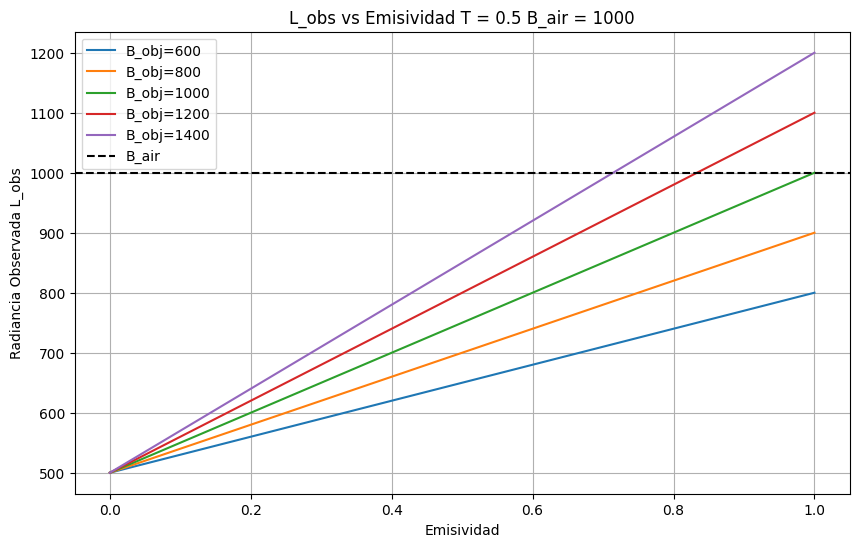

In [ ]:
T_fijo = 0.5
valores_emisividad = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 6))
for b in B_obj:
    L_obj = T_fijo * valores_emisividad * b
    L_air = (1 - T_fijo) * B_air
    L_obs = L_obj + L_air
    plt.plot(valores_emisividad, L_obs, label=f"B_obj={b}")
plt.axhline(B_air, color='k', linestyle='dashed', label='B_air')
plt.xlabel("Emisividad")
plt.ylabel("Radiancia Observada L_obs")
plt.title("L_obs vs Emisividad T = " + str(T_fijo) + " B_air = " + str(B_air))
plt.legend()
plt.grid(True)
plt.show()

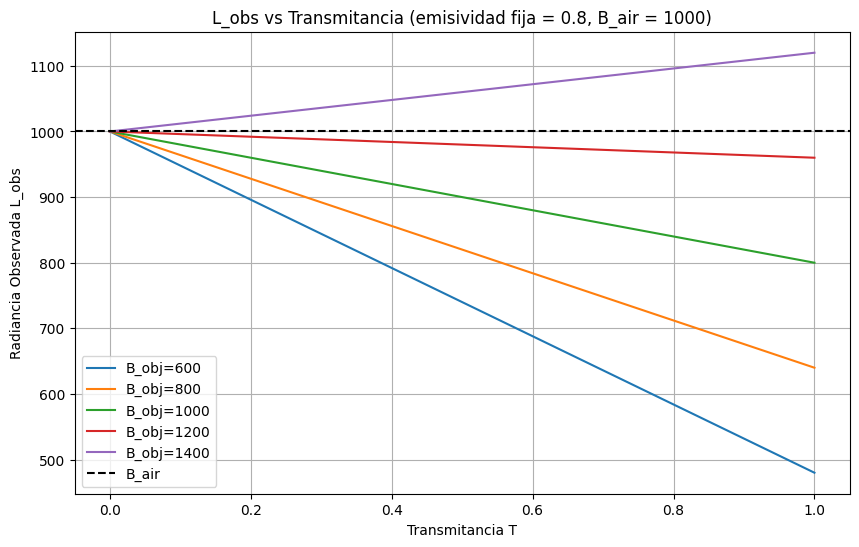

In [ ]:
emisividad_fija = 0.8
valores_T = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 6))
for b in B_obj:
    L_obj = valores_T * emisividad_fija * b
    L_air = (1 - valores_T) * B_air
    L_obs = L_obj + L_air
    plt.plot(valores_T, L_obs, label=f"B_obj={b}")
plt.axhline(B_air, color='k', linestyle='dashed', label='B_air')
plt.xlabel("Transmitancia T")
plt.ylabel("Radiancia Observada L_obs")
plt.title(f"L_obs vs Transmitancia (emisividad fija = {emisividad_fija}, B_air = {B_air})")
plt.legend()
plt.grid(True)
plt.show()